In [1]:
import numpy as np
from scipy import integrate, optimize
import matplotlib.pyplot as plt

https://stackoverflow.com/questions/79508027/graphing-nonlinear-systems-of-odes-in-python

In [2]:
K = 17.3
epsilon = 4.9
r = 2.7
mu = 0.9
gamma = 3.2  
alpha = 4 / (K - epsilon) ** 2  

In [3]:
def model(t, y, alpha, r, K, epsilon, mu, gamma):
    return np.array([
        gamma * y[1] / (1 + y[1]) - mu * y[0],
        alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]
    ])

In [4]:
M0 = 5.6667
N0 = K / 1.5

In [5]:
Mvec = np.linspace(-1, 1, 20)
Nvec = np.linspace(-1, 1, 20)
Mlin = np.linspace(-1, 1, 200)
Nlin = np.linspace(-1, 1, 200)
Mv, Nv = np.meshgrid(Mvec, Nvec)
Ml, Nl = np.meshgrid(Mlin, Nlin)

In [6]:
t = np.linspace(2, 10, 200)

In [7]:
p0 = (alpha, r, K, epsilon, mu, gamma)
p0

(0.02601456815816857, 2.7, 17.3, 4.9, 0.9, 3.2)

In [8]:
Uv, Vv = model(t, [Mv, Nv], *p0)
Ul, Vl = model(t, [Ml, Nl], *p0)
Cv = np.sqrt(Uv ** 2 + Vv ** 2)
Cl = np.sqrt(Ul ** 2 + Vl ** 2)

/tmp/ipykernel_588/4181885818.py:3: RuntimeWarning: divide by zero encountered in divide
  gamma * y[1] / (1 + y[1]) - mu * y[0],
/tmp/ipykernel_588/4181885818.py:4: RuntimeWarning: divide by zero encountered in divide
  alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]


In [9]:
def proxy(x, *args):
    return model(None, x, *args)

In [10]:
sol0 = optimize.root(proxy, x0=[0.025, 0.01], args=p0, tol=1e-3)

/tmp/ipykernel_588/4181885818.py:4: RuntimeWarning: invalid value encountered in scalar divide
  alpha * r * (y[1] ** 2 / (y[1] + y[0])) * (K - y[1]) * (y[1] - epsilon) - mu * y[1]


In [11]:
sol1 = optimize.root(proxy, x0=[5, 7.5], args=p0)

In [12]:
sol2 = optimize.root(proxy, x0=[2.5, 17.5], args=p0)

In [13]:
y0 = (M0, N0)
y1 = (4, 6)
y2 = (10, 2.5)

In [14]:
ivp0 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y0, t_eval=t)
ivp1 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y1, t_eval=t)
ivp2 = integrate.solve_ivp(model, [t.min(), t.max()], args=p0, y0=y2, t_eval=t)

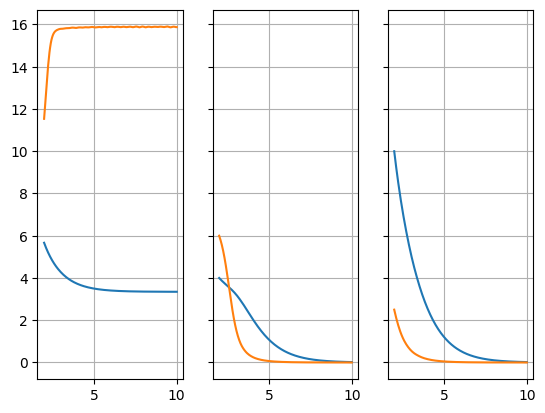

In [15]:
fig, axes = plt.subplots(1, 3, sharex=True, sharey=True)
for i, ivp in enumerate([ivp0, ivp1, ivp2]):
    axes[i].plot(t, ivp.y.T)
    axes[i].grid()
#axe.set_title("Solutions")
#axe.set_xlabel("$t$")
#axe.set_ylabel("$y(t)$")
#axe.legend(["$M$", "$N$"])

Text(0.5, 1.0, 'Phase diagram')

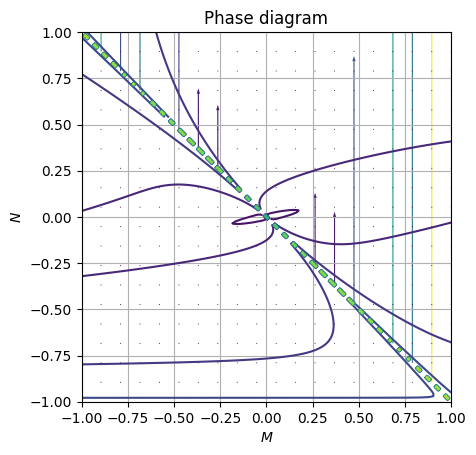

In [16]:
fig, axe = plt.subplots()
#axe.scatter(*y0)
#axe.plot(*ivp0.y)
#axe.scatter(*y1)
#axe.plot(*ivp1.y)
#axe.scatter(*y2)
#axe.plot(*ivp2.y)
axe.quiver(Mv, Nv, Uv, Vv, Cv)
axe.contour(Ml, Nl, np.log(Cl), 20)
#axe.scatter(*sol0.x)
#axe.scatter(*sol1.x)
#axe.scatter(*sol2.x)
axe.grid()
axe.set_aspect("equal")
axe.set_xlabel("$M$")
axe.set_ylabel("$N$")
axe.set_title("Phase diagram")